In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, RobustScaler
from sklearn.model_selection import train_test_split
import joblib
import pickle

import warnings
warnings.filterwarnings('ignore')


In [2]:
# Installer les outils nécessaires
!pip install --upgrade google-cloud-storage


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.9/174.9 kB 3.0 MB/s eta 0:00:00
  Attempting uninstall: google-cloud-storage
    Found existing installation: google-cloud-storage 2.19.0
    Uninstalling google-cloud-storage-2.19.0:
      Successfully uninstalled google-cloud-storage-2.19.0


In [ ]:
# Authentification Google
from google.colab import auth
auth.authenticate_user()

In [3]:
# Bibliothèques
from google.cloud import storage
import pandas as pd

In [4]:
# Client sans authentification (accès public)
client = storage.Client.create_anonymous_client()

# Son bucket et fichier
bucket_name =  'mon-bucket-22go' # Doit être public
blob_name = 'ddos.csv'
local_path = '/content/ddos.csv'

# Téléchargement
bucket = client.bucket(bucket_name)
blob = bucket.blob(blob_name)
blob.download_to_filename(local_path)
print("✅ Fichier téléchargé (bucket public)")

df = pd.read_csv(local_path)
df.head()

✅ Fichier téléchargé (bucket public)


,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,SimillarHTTP,Inbound,Label
0,0,172.16.0.5-192.168.50.1-60675-80-6,172.16.0.5,60675,192.168.50.1,80,6,2018-12-01 09:17:11.183810,5220876,12,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,205.174.165.72/c.php,1,DrDoS_NTP
1,7,172.16.0.5-192.168.50.1-60676-80-6,172.16.0.5,60676,192.168.50.1,80,6,2018-12-01 09:17:11.205636,12644252,5,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0,1,DrDoS_NTP
2,12858,192.168.50.7-65.55.163.78-50458-443-6,65.55.163.78,443,192.168.50.7,50458,6,2018-12-01 09:17:12.634569,3,2,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0,1,BENIGN
3,10191,192.168.50.7-65.55.163.78-50465-443-6,65.55.163.78,443,192.168.50.7,50465,6,2018-12-01 09:17:13.458370,3,2,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0,1,BENIGN
4,239,192.168.50.253-224.0.0.5-0-0-0,192.168.50.253,0,224.0.0.5,0,0,2018-12-01 09:17:13.470913,114329232,52,...,2.466441,15.0,6.0,9527428.0,248706.681286,9950741.0,9092248.0,0,0,BENIGN


In [5]:
df.shape

(50063112, 88)

In [6]:
# Supprimer les espaces avant/après les noms de colonnes
df.columns = df.columns.str.strip()

# Refaire un print propre
print(df.columns.tolist())

['Unnamed: 0', 'Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag

In [7]:
# Afficher les valeurs uniques et leur nombre
print(df["Label"].value_counts())

Label
TFTP             20082580
DrDoS_SNMP        5159870
DrDoS_DNS         5071011
DrDoS_MSSQL       4522492
DrDoS_NetBIOS     4093279
DrDoS_UDP         3134645
DrDoS_SSDP        2610611
DrDoS_LDAP        2179930
Syn               1582289
DrDoS_NTP         1202642
UDP-lag            366461
BENIGN              56863
WebDDoS               439
Name: count, dtype: int64


In [8]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    accuracy_score,
    f1_score,
    precision_recall_curve
)
from sklearn.preprocessing import LabelEncoder

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

In [9]:
# Étape 2 : Remplacement des valeurs infinies (+inf, -inf) par NaN
# (obligatoire car Random Forest de scikit-learn ne les accepte pas)
df.replace([np.inf, -np.inf], np.nan, inplace=True)


In [10]:
# Encodage robuste : BENIGN → 0, autres → 1
df["Label"] = df["Label"].apply(lambda x: 0 if str(x).strip().upper() == "BENIGN" else 1)


In [11]:
# Étape 4 : Encodage minimaliste des autres colonnes non numériques
# Aucune sémantique : juste pour rendre les colonnes compatibles avec Random Forest
for col in df.select_dtypes(include=['object', 'category']).columns:
    if col != "Label":  # On ne réencode pas 'Label' ici, déjà fait
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))


In [12]:
# Étape 5 : Remplacement des valeurs manquantes par une valeur arbitraire
# (valeur aberrante pour signaler une anomalie sans imputation réelle)
df.fillna(-999999, inplace=True)

In [13]:
print(df["Label"].value_counts())

Label
1    50006249
0       56863
Name: count, dtype: int64


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50063112 entries, 0 to 50063111
Data columns (total 88 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Unnamed: 0                   int64  
 1   Flow ID                      int64  
 2   Source IP                    int64  
 3   Source Port                  int64  
 4   Destination IP               int64  
 5   Destination Port             int64  
 6   Protocol                     int64  
 7   Timestamp                    int64  
 8   Flow Duration                int64  
 9   Total Fwd Packets            int64  
 10  Total Backward Packets       int64  
 11  Total Length of Fwd Packets  float64
 12  Total Length of Bwd Packets  float64
 13  Fwd Packet Length Max        float64
 14  Fwd Packet Length Min        float64
 15  Fwd Packet Length Mean       float64
 16  Fwd Packet Length Std        float64
 17  Bwd Packet Length Max        float64
 18  Bwd Packet Length Min        float64
 19

In [15]:
# Étape 6 : Séparation des variables explicatives (X) et de la variable cible (y)
X = df.drop("Label", axis=1)
y = df["Label"]

In [16]:
# Étape 7 : Division en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [17]:
X_train.info()
X_test.info()
y_train.info()
y_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35044178 entries, 1459949 to 36315509
Data columns (total 87 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Unnamed: 0                   int64  
 1   Flow ID                      int64  
 2   Source IP                    int64  
 3   Source Port                  int64  
 4   Destination IP               int64  
 5   Destination Port             int64  
 6   Protocol                     int64  
 7   Timestamp                    int64  
 8   Flow Duration                int64  
 9   Total Fwd Packets            int64  
 10  Total Backward Packets       int64  
 11  Total Length of Fwd Packets  float64
 12  Total Length of Bwd Packets  float64
 13  Fwd Packet Length Max        float64
 14  Fwd Packet Length Min        float64
 15  Fwd Packet Length Mean       float64
 16  Fwd Packet Length Std        float64
 17  Bwd Packet Length Max        float64
 18  Bwd Packet Length Min        float64
 1

In [25]:
# Entraînement avec mesure du temps
start_train = time.time()
# Étape 8 : Entraînement rapide du modèle Random Forest (optimisé pour dataset volumineux)
model = RandomForestClassifier(
    n_estimators=10,
    max_depth=10,
    max_features='sqrt',
    min_samples_split=10,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced'
)
model.fit(X_train, y_train)
end_train = time.time()

In [26]:
import joblib
# Sauvegarde du modèle dans un fichier .pkl
joblib.dump(model, 'modelv1_random_forest_fin.pkl')


['modelv1_random_forest_fin.pkl']

In [59]:
print(type(model))

<class 'sklearn.calibration.CalibratedClassifierCV'>


In [60]:
modelrf = joblib.load('modelv1_random_forest_fin.pkl')

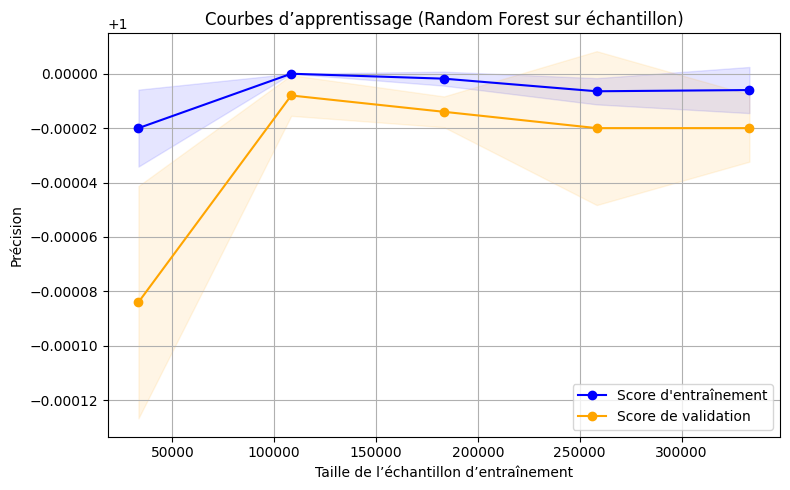

In [61]:
from sklearn.model_selection import learning_curve
from sklearn.utils import resample
import matplotlib.pyplot as plt
import numpy as np

# Échantillonnage stratifié pour un sous-ensemble de 500 000 exemples
X_sample, y_sample = resample(X_train, y_train, n_samples=500000, random_state=42)

# Génération des courbes d’apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    modelrf, X_sample, y_sample, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'
)

# Moyennes et écarts-types
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Visualisation
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label="Score d'entraînement", color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', label="Score de validation", color='orange')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.title("Courbes d’apprentissage (Random Forest sur échantillon)")
plt.xlabel("Taille de l’échantillon d’entraînement")
plt.ylabel("Précision")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.savefig("learning_curve_train_rf_v1.png")
plt.show()

In [57]:
modelnb = joblib.load('modelv1_naive_bayes_final.pkl')

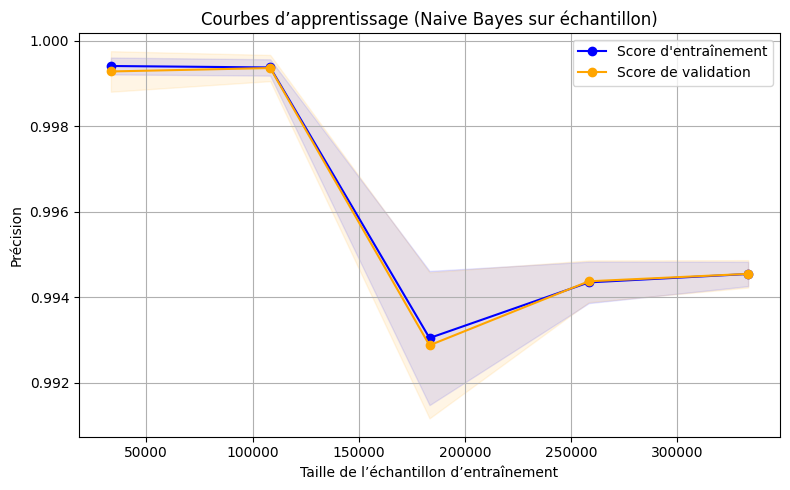

In [58]:
from sklearn.model_selection import learning_curve
from sklearn.utils import resample
import matplotlib.pyplot as plt
import numpy as np

# Échantillonnage stratifié pour un sous-ensemble de 500 000 exemples
X_sample, y_sample = resample(X_train, y_train, n_samples=500000, random_state=42)

# Génération des courbes d’apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    modelnb, X_sample, y_sample, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'
)

# Moyennes et écarts-types
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Visualisation
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label="Score d'entraînement", color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', label="Score de validation", color='orange')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.title("Courbes d’apprentissage (Naive Bayes sur échantillon)")
plt.xlabel("Taille de l’échantillon d’entraînement")
plt.ylabel("Précision")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.savefig("learning_curve_train_nb_v1.png")
plt.show()

In [47]:
# Sélection de 1 000 000 échantillons pour l'entraînement
X_train_small, _, y_train_small, _ = train_test_split(
    X_train, y_train,
    train_size=1_000_000,
    stratify=y_train,
    random_state=42
)

In [48]:
X_test_small, _, y_test_small, _ = train_test_split(
    X_test, y_test,
    train_size=500_000,
    stratify=y_test,
    random_state=42
)

In [49]:
modelknn = joblib.load('modelv1_knn_final.pkl')

ValueError: EOF: reading array data, expected 262144 bytes got 123488

In [ ]:
from sklearn.model_selection import learning_curve
from sklearn.utils import resample
import matplotlib.pyplot as plt
import numpy as np

# Échantillonnage stratifié pour un sous-ensemble de 500 000 exemples
X_sample, y_sample = resample(X_train, y_train, n_samples=500000, random_state=42)

# Génération des courbes d’apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    modelknn, X_sample, y_sample, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'
)

# Moyennes et écarts-types
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Visualisation
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label="Score d'entraînement", color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', label="Score de validation", color='orange')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.title("Courbes d’apprentissage (Random Forest sur échantillon)")
plt.xlabel("Taille de l’échantillon d’entraînement")
plt.ylabel("Précision")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.savefig("learning_curve_train_v1.png")
plt.show()

In [51]:
modelsvm = joblib.load('modelv1_linearsvc_final.pkl')

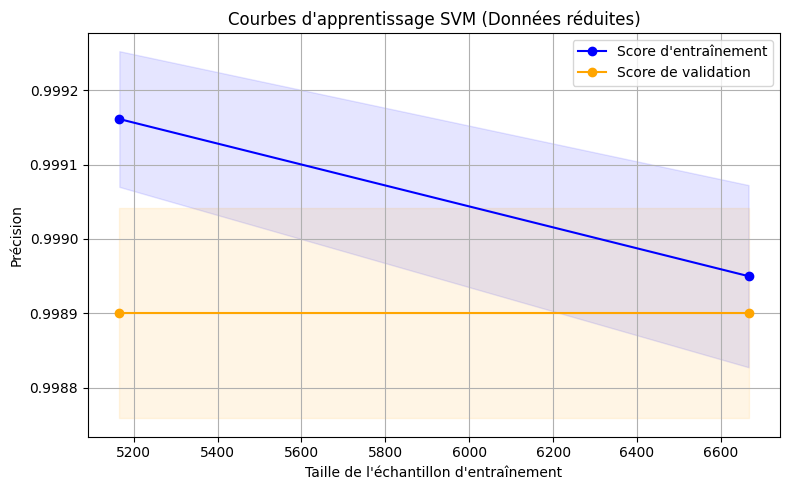

In [56]:
from sklearn.model_selection import learning_curve
from sklearn.utils import resample
import matplotlib.pyplot as plt
import numpy as np

# Courbes d'apprentissage (sur sous-ensemble)
sample_size = min(10000, len(X_train_small))
X_sample, y_sample = resample(X_train_small, y_train_small, n_samples=sample_size, random_state=42)

train_sizes, train_scores, test_scores = learning_curve(
    modelsvm, X_sample, y_sample, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label="Score d'entraînement", color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', label="Score de validation", color='orange')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.title("Courbes d'apprentissage SVM (Données réduites)")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Précision")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.savefig("learning_curve_svm_v1.png")
plt.show()

In [54]:
modelxg = joblib.load('modelv1_xgboost_final.pkl')

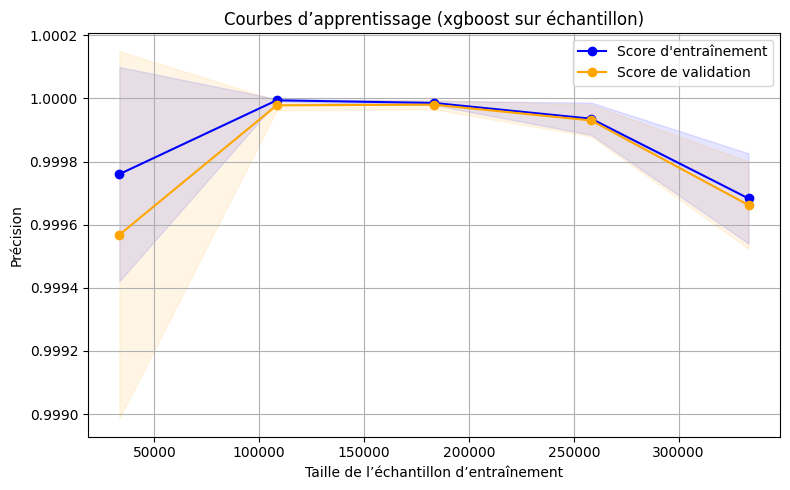

In [55]:
from sklearn.model_selection import learning_curve
from sklearn.utils import resample
import matplotlib.pyplot as plt
import numpy as np

# Échantillonnage stratifié pour un sous-ensemble de 500 000 exemples
X_sample, y_sample = resample(X_train, y_train, n_samples=500000, random_state=42)

# Génération des courbes d’apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    modelxg, X_sample, y_sample, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'
)

# Moyennes et écarts-types
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Visualisation
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label="Score d'entraînement", color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', label="Score de validation", color='orange')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.title("Courbes d’apprentissage (xgboost sur échantillon)")
plt.xlabel("Taille de l’échantillon d’entraînement")
plt.ylabel("Précision")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.savefig("learning_curve_train_xg_v1.png")
plt.show()